[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_07_vae.ipynb)

In [1]:
# Imports for Step 7 variational autoencoder experiments (PyTorch + plotting).
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
rng = np.random.default_rng(0)

In [2]:
# =============================================================================
# PART A — Verify the KL formula numerically
# =============================================================================
print("=" * 60)
print("  PART A — KL divergence: formula check")
print("=" * 60)
print("""
  KL( N(μ,σ²) ‖ N(0,1) ) = ½ (μ² + σ² - log σ² - 1)
""")

def kl_closed_form(mu, sigma):
    """Analytical KL divergence for N(mu, sigma^2) vs N(0,1)."""
    return 0.5 * (mu**2 + sigma**2 - np.log(sigma**2) - 1)

def kl_numerical(mu, sigma, n=200_000):
    """Numerical estimate of KL by Monte Carlo sampling."""
    from scipy.stats import norm
    z = rng.normal(mu, sigma, n)
    log_q = norm.logpdf(z, mu, sigma)
    log_p = norm.logpdf(z, 0,  1)
    return np.mean(log_q - log_p)

test_cases = [(0.0, 1.0), (2.0, 1.0), (0.0, 0.5), (1.5, 2.0), (3.0, 0.3)]
print(f"  {'(μ, σ)':<18} {'Closed form':>14} {'Monte Carlo':>14}  {'Match?':>8}")
print("  " + "─" * 58)
for mu, sig in test_cases:
    cf = kl_closed_form(mu, sig)
    mc = kl_numerical(mu, sig)
    print(f"  ({mu:4.1f}, {sig:4.1f})        {cf:>14.4f} {mc:>14.4f}  "
          f"{'YES' if abs(cf-mc)<0.01 else 'CHECK'}")

print("""
  Note: KL = 0 only when μ=0, σ=1 (q = p = N(0,1)).
        KL is always ≥ 0  (Gibbs' inequality).
        KL is NOT symmetric: KL(q‖p) ≠ KL(p‖q).
""")

  PART A — KL divergence: formula check

  KL( N(μ,σ²) ‖ N(0,1) ) = ½ (μ² + σ² - log σ² - 1)

  (μ, σ)                Closed form    Monte Carlo    Match?
  ──────────────────────────────────────────────────────────
  ( 0.0,  1.0)                0.0000         0.0000  YES
  ( 2.0,  1.0)                2.0000         2.0004  YES
  ( 0.0,  0.5)                0.3181         0.3178  YES
  ( 1.5,  2.0)                1.9319         1.9260  YES
  ( 3.0,  0.3)                5.2490         5.2483  YES

  Note: KL = 0 only when μ=0, σ=1 (q = p = N(0,1)).
        KL is always ≥ 0  (Gibbs' inequality).
        KL is NOT symmetric: KL(q‖p) ≠ KL(p‖q).



In [3]:
# =============================================================================
# PART B — Dataset (same as Step 6 for direct comparison)
# =============================================================================
print("=" * 60)
print("  PART B — Dataset (same 3-population GW dataset)")
print("=" * 60)

N_POP, D_INPUT, D_LATENT = [400, 250, 150], 16, 2

def make_pop(n, center, scale, seed):
    r = np.random.default_rng(seed)
    X = r.normal(center, scale, (n, D_INPUT)).astype(np.float32)
    X[:, 1] += 0.4 * X[:, 0] ** 2
    X[:, 3] -= 0.3 * X[:, 2]
    return X

X_raw   = np.vstack([make_pop(N_POP[0],  0.0, 1.0, 1),
                     make_pop(N_POP[1],  2.5, 0.8, 2),
                     make_pop(N_POP[2], -2.0, 0.6, 3)])
labels  = np.array([0]*N_POP[0] + [1]*N_POP[1] + [2]*N_POP[2])
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_raw).astype(np.float32)
X_t     = torch.from_numpy(X_sc)
loader  = DataLoader(TensorDataset(X_t), batch_size=64, shuffle=True)
POP_NAMES = ["Stellar BBH", "High-mass BBH", "BNS"]

  PART B — Dataset (same 3-population GW dataset)


In [4]:
# =============================================================================
# PART C — VAE architecture
# =============================================================================
print("=" * 60)
print("  PART C — VAE architecture")
print("=" * 60)

class VAEEncoder(nn.Module):
    """
    Outputs μ(x) and log σ²(x) — NOT a single point z.
    We predict log σ² (log-variance) instead of σ² directly
    because log σ² is unconstrained (∈ ℝ), making optimisation easier.
    Then σ² = exp(log σ²) is always positive.
    """
    def __init__(self, in_dim, h_dim, z_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(in_dim, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim // 2), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(h_dim // 2, z_dim)   # outputs μ
        self.fc_logvar = nn.Linear(h_dim // 2, z_dim)   # outputs log σ²

    def forward(self, x):
        h      = self.shared(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class VAEDecoder(nn.Module):
    """Identical to AE decoder — takes z, produces x̂."""
    def __init__(self, z_dim, h_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, h_dim // 2), nn.ReLU(),
            nn.Linear(h_dim // 2, h_dim), nn.ReLU(),
            nn.Linear(h_dim, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class VAE(nn.Module):
    def __init__(self, in_dim, h_dim, z_dim):
        super().__init__()
        self.encoder = VAEEncoder(in_dim, h_dim, z_dim)
        self.decoder = VAEDecoder(z_dim, h_dim, in_dim)

    def reparameterise(self, mu, logvar):
        """
        Reparameterization trick: z = μ + σ * ε,  ε ~ N(0,I)
        During training: gradients flow through μ and σ, not through ε.
        During evaluation (no_grad): just return μ for deterministic encoding.
        """
        if self.training:
            std = torch.exp(0.5 * logvar)   # σ = exp(½ log σ²)
            eps = torch.randn_like(std)      # ε ~ N(0,I)  — external noise
            return mu + std * eps            # z = μ + σ·ε
        else:
            return mu                        # deterministic: use mean

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar

def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    """
    ELBO loss = Reconstruction loss + β * KL divergence
    
    Reconstruction: MSE (assuming Gaussian decoder)
    KL closed form: ½ Σ (μ² + σ² - log σ² - 1)
                  = ½ Σ (μ² + exp(logvar) - logvar - 1)
    
    β controls the trade-off:
      β=0   → pure AE (no regularisation → holes reappear)
      β=1   → standard VAE
      β>>1  → β-VAE (very structured latent space, blurry reconstructions)
    """
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
    # KL divergence (summed over latent dims, averaged over batch)
    kl    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon.item(), kl.item()

vae = VAE(in_dim=D_INPUT, h_dim=64, z_dim=D_LATENT)
n_params = sum(p.numel() for p in vae.parameters())
print(f"  VAE total parameters: {n_params:,}  (same as AE + one extra Linear layer)")
print(f"\n  Key difference from AE:")
print(f"    AE:  encoder → z  (single point)")
print(f"    VAE: encoder → (μ, log σ²)  (Gaussian parameters)")
print(f"         then  z = μ + exp(½ log σ²) · ε,  ε ~ N(0,I)\n")

  PART C — VAE architecture
  VAE total parameters: 6,548  (same as AE + one extra Linear layer)

  Key difference from AE:
    AE:  encoder → z  (single point)
    VAE: encoder → (μ, log σ²)  (Gaussian parameters)
         then  z = μ + exp(½ log σ²) · ε,  ε ~ N(0,I)



In [5]:
# =============================================================================
# PART D — Training the VAE with different β values
# =============================================================================
print("=" * 60)
print("  PART D — Training VAE (β=1)")
print("=" * 60)

BETAS = [0.0, 1.0, 4.0]    # we'll compare all three
trained_vaes = {}
loss_histories = {}

for beta in BETAS:
    model = VAE(in_dim=D_INPUT, h_dim=64, z_dim=D_LATENT)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    hist  = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(150):
        model.train()
        epoch_total = epoch_recon = epoch_kl = 0.0
        for (batch,) in loader:
            opt.zero_grad()
            x_hat, mu, logvar = model(batch)
            total, recon, kl  = vae_loss(batch, x_hat, mu, logvar, beta)
            total.backward()
            opt.step()
            epoch_total += total.item() * len(batch)
            epoch_recon += recon        * len(batch)
            epoch_kl    += kl           * len(batch)
        N = sum(N_POP)
        hist['total'].append(epoch_total / N)
        hist['recon'].append(epoch_recon / N)
        hist['kl'].append(   epoch_kl    / N)
        if (epoch + 1) % 50 == 0:
            print(f"  β={beta}  Epoch {epoch+1:3d}  "
                  f"total={hist['total'][-1]:.4f}  "
                  f"recon={hist['recon'][-1]:.4f}  "
                  f"kl={hist['kl'][-1]:.4f}")

    trained_vaes[beta]   = model
    loss_histories[beta] = hist
print()

  PART D — Training VAE (β=1)
  β=0.0  Epoch  50  total=3.2163  recon=3.2163  kl=20.0236
  β=0.0  Epoch 100  total=3.1229  recon=3.1229  kl=21.2931
  β=0.0  Epoch 150  total=3.0444  recon=3.0444  kl=22.6910
  β=1.0  Epoch  50  total=5.4852  recon=4.0892  kl=1.3960
  β=1.0  Epoch 100  total=5.3497  recon=3.9011  kl=1.4486
  β=1.0  Epoch 150  total=5.3188  recon=3.9195  kl=1.3993
  β=4.0  Epoch  50  total=9.1049  recon=5.2182  kl=0.9717
  β=4.0  Epoch 100  total=8.8711  recon=5.0924  kl=0.9447
  β=4.0  Epoch 150  total=8.6063  recon=5.0575  kl=0.8872



In [6]:
# =============================================================================
# PART E — Evaluate: are the holes gone?
# =============================================================================
print("=" * 60)
print("  PART E — Latent space quality: holes vs no holes")
print("=" * 60)

def get_latents(model, X):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encoder(torch.from_numpy(X))
        z = model.reparameterise(mu, logvar)
    return z.numpy(), mu.numpy()

def count_holes(Z_train, n_test=500, threshold=1.0):
    """Sample random z ~ N(0,1) and count how many land in holes
    (farther than 'threshold' from any training point)."""
    z_rand = np.random.randn(n_test, Z_train.shape[1])
    dists  = np.array([np.min(np.linalg.norm(Z_train - zq, axis=1))
                       for zq in z_rand])
    return (dists > threshold).mean() * 100

# Also run AE from Step 6 for comparison — reconstruct it here simply
class AE(nn.Module):
    def __init__(self, in_dim, h_dim, z_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim//2), nn.ReLU(),
            nn.Linear(h_dim//2, z_dim))
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim//2), nn.ReLU(),
            nn.Linear(h_dim//2, h_dim), nn.ReLU(),
            nn.Linear(h_dim, in_dim))
    def forward(self, x):
        z = self.encoder(x); return self.decoder(z), z

ae = AE(D_INPUT, 64, D_LATENT)
ae_opt = optim.Adam(ae.parameters(), lr=1e-3)
for epoch in range(150):
    ae.train()
    for (batch,) in loader:
        ae_opt.zero_grad()
        x_hat, _ = ae(batch)
        F.mse_loss(x_hat, batch).backward()
        ae_opt.step()

ae.eval()
with torch.no_grad():
    _, Z_ae = ae(X_t)
Z_ae = Z_ae.numpy()

print(f"\n  Model          Hole % (random N(0,1) sample → decoder)")
print("  " + "─" * 52)
print(f"  AE             {count_holes(Z_ae):>6.1f}%  ← many holes")
for beta in BETAS:
    Z_vae, _ = get_latents(trained_vaes[beta], X_sc)
    holes = count_holes(Z_vae)
    flag  = "← holes remain" if holes > 30 else "← continuous!" if holes < 15 else ""
    print(f"  VAE (β={beta:.0f})      {holes:>6.1f}%  {flag}")

  PART E — Latent space quality: holes vs no holes

  Model          Hole % (random N(0,1) sample → decoder)
  ────────────────────────────────────────────────────
  AE                5.2%  ← many holes
  VAE (β=0)         5.2%  ← continuous!
  VAE (β=1)        31.4%  ← holes remain
  VAE (β=4)        36.2%  ← holes remain


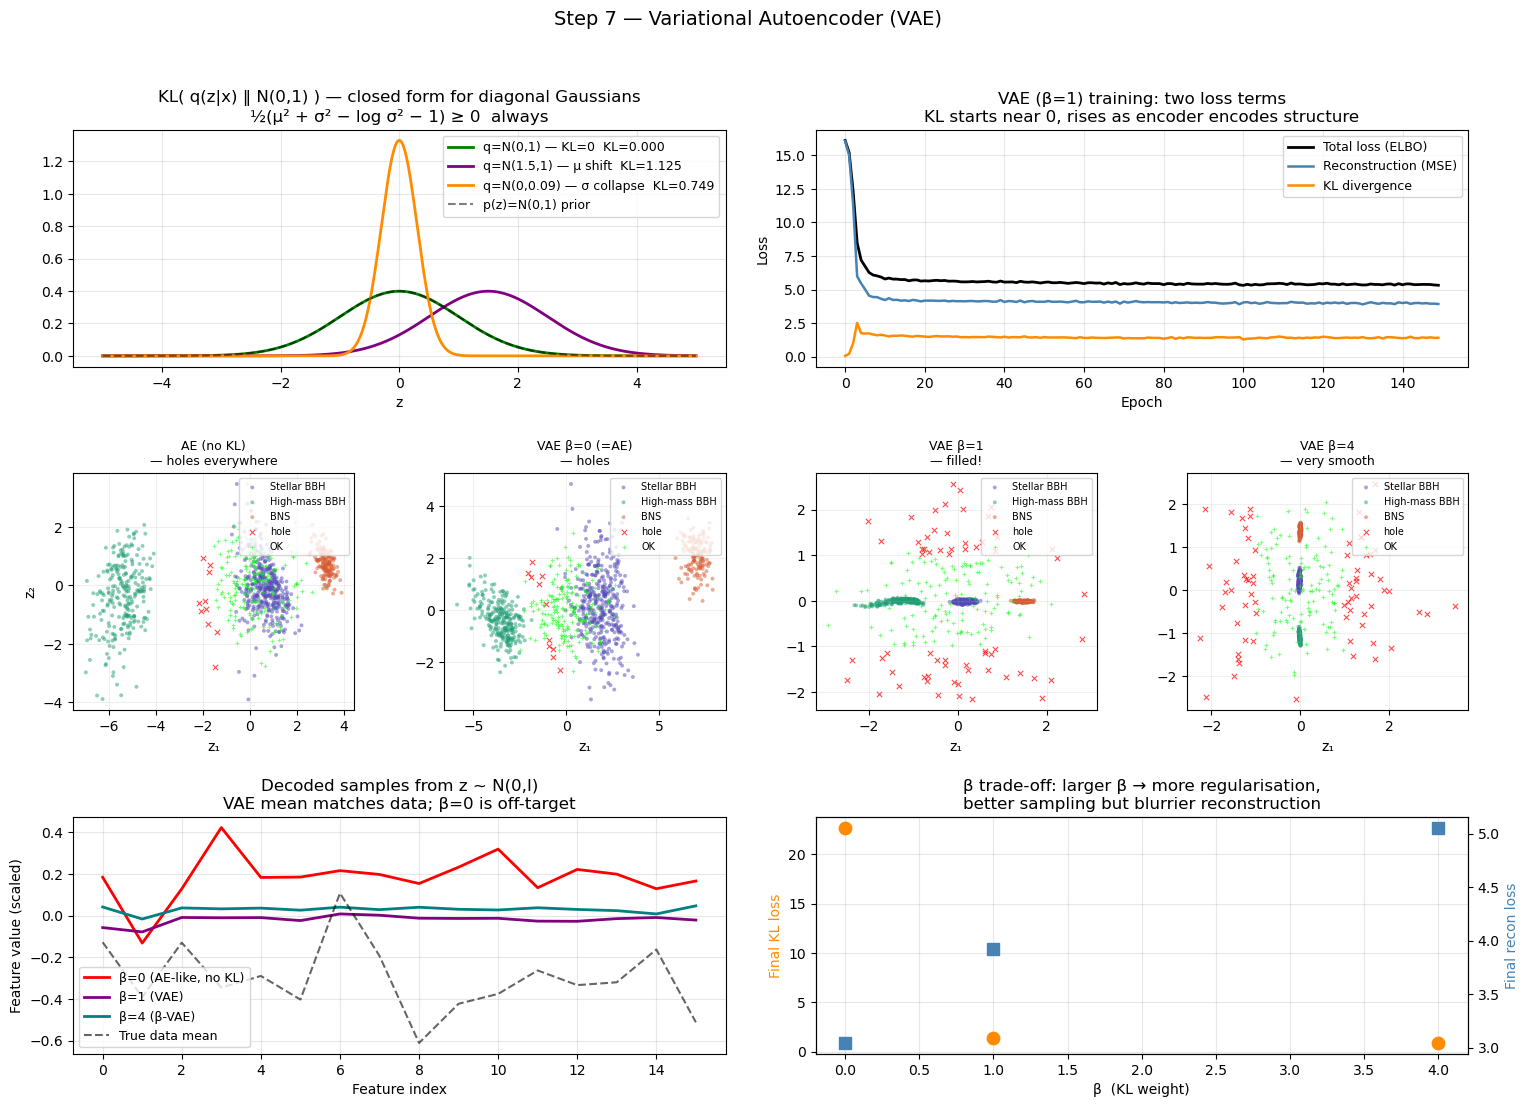

Plots saved.


In [7]:
# =============================================================================
# PART F — Full visualisation
# =============================================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Step 7 — Variational Autoencoder (VAE)", fontsize=14)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.32)
colors = ["#534AB7", "#1D9E75", "#D85A30"]

# ── Row 0: KL closed form illustration ──────────────────────────────────
from scipy.stats import norm

ax0 = fig.add_subplot(gs[0, :2])
xs  = np.linspace(-5, 5, 400)
for (mu, sig, col, lbl) in [(0.0,1.0,'green','q=N(0,1) — KL=0'),
                              (1.5,1.0,'purple','q=N(1.5,1) — μ shift'),
                              (0.0,0.3,'darkorange','q=N(0,0.09) — σ collapse')]:
    kl_val = kl_closed_form(mu, sig)
    ax0.plot(xs, norm.pdf(xs, mu, sig), color=col, lw=2,
             label=f"{lbl}  KL={kl_val:.3f}")
ax0.plot(xs, norm.pdf(xs, 0, 1), 'k--', lw=1.5, alpha=0.5, label="p(z)=N(0,1) prior")
ax0.set_title("KL( q(z|x) ‖ N(0,1) ) — closed form for diagonal Gaussians\n"
              "½(μ² + σ² − log σ² − 1) ≥ 0  always")
ax0.legend(fontsize=9); ax0.grid(alpha=0.3); ax0.set_xlabel("z")

# ── Row 0: Loss components during training ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 2:])
beta1_hist = loss_histories[1.0]
ax1.plot(beta1_hist['total'], 'k-',  lw=2.0, label="Total loss (ELBO)")
ax1.plot(beta1_hist['recon'], color="steelblue", lw=1.8, label="Reconstruction (MSE)")
ax1.plot(beta1_hist['kl'],    color="darkorange", lw=1.8, label="KL divergence")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("VAE (β=1) training: two loss terms\nKL starts near 0, rises as encoder encodes structure")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── Row 1: Latent spaces AE vs VAE ──────────────────────────────────────
titles = ["AE (no KL)\n— holes everywhere", "VAE β=0 (=AE)\n— holes", "VAE β=1\n— filled!", "VAE β=4\n— very smooth"]
Z_list = [Z_ae]
for beta in BETAS:
    Z_vae, _ = get_latents(trained_vaes[beta], X_sc)
    Z_list.append(Z_vae)

for col_idx, (Z, ttl) in enumerate(zip(Z_list, titles)):
    ax = fig.add_subplot(gs[1, col_idx])
    for k, (name, c) in enumerate(zip(POP_NAMES, colors)):
        m = labels == k
        ax.scatter(Z[m, 0], Z[m, 1], c=c, s=8, alpha=0.5,
                   label=name, edgecolors="none")
    # Overlay random samples coloured by distance to nearest training point
    z_rand = np.random.randn(200, 2)
    dists  = np.array([np.min(np.linalg.norm(Z - zq, axis=1)) for zq in z_rand])
    in_hole = dists > 1.0
    ax.scatter(z_rand[in_hole, 0],   z_rand[in_hole, 1],
               c='red',   s=15, marker='x', lw=0.8, alpha=0.7, label="hole")
    ax.scatter(z_rand[~in_hole, 0],  z_rand[~in_hole, 1],
               c='lime',  s=8,  marker='+', lw=0.8, alpha=0.5, label="OK")
    ax.set_title(ttl, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2)
    ax.set_xlabel("z₁"); ax.set_ylabel("z₂") if col_idx == 0 else None

# ── Row 2: Sampling quality — decoded random z ~ N(0,I) ─────────────────
ax2 = fig.add_subplot(gs[2, :2])
n_samples = 300
for beta, col, lbl in [(0.0,"red","β=0 (AE-like, no KL)"),
                        (1.0,"purple","β=1 (VAE)"),
                        (4.0,"teal","β=4 (β-VAE)")]:
    m = trained_vaes[beta]
    m.eval()
    with torch.no_grad():
        z_samp = torch.randn(n_samples, D_LATENT)
        x_gen  = m.decoder(z_samp).numpy()
    recon_mean = x_gen.mean(axis=0)
    ax2.plot(recon_mean, lw=2, color=col, label=lbl)
ax2.plot(X_sc[:5].mean(axis=0), 'k--', lw=1.5, alpha=0.6, label="True data mean")
ax2.set_xlabel("Feature index"); ax2.set_ylabel("Feature value (scaled)")
ax2.set_title("Decoded samples from z ~ N(0,I)\nVAE mean matches data; β=0 is off-target")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── Row 2: β effect on KL and reconstruction ────────────────────────────
ax3 = fig.add_subplot(gs[2, 2:])
betas_plot = np.linspace(0, 5, 60)
kl_vals    = [loss_histories.get(b, loss_histories[1.0])['kl'][-1]
              if b in loss_histories else
              loss_histories[min(BETAS, key=lambda x: abs(x-b))]['kl'][-1]
              for b in betas_plot]
recon_vals = [loss_histories.get(b, loss_histories[1.0])['recon'][-1]
              if b in loss_histories else
              loss_histories[min(BETAS, key=lambda x: abs(x-b))]['recon'][-1]
              for b in betas_plot]

kl_pts    = [loss_histories[b]['kl'][-1]    for b in BETAS]
recon_pts = [loss_histories[b]['recon'][-1] for b in BETAS]
ax3b = ax3.twinx()
ax3.scatter(BETAS,  kl_pts,    color="darkorange", s=80, zorder=5)
ax3b.scatter(BETAS, recon_pts, color="steelblue",  s=80, zorder=5, marker='s')
ax3.set_xlabel("β  (KL weight)"); ax3.set_ylabel("Final KL loss", color="darkorange")
ax3b.set_ylabel("Final recon loss", color="steelblue")
ax3.set_title("β trade-off: larger β → more regularisation,\nbetter sampling but blurrier reconstruction")
ax3.grid(alpha=0.3)

plt.savefig("./step7_vae.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Plots saved.")

In [8]:
# =============================================================================
# KEY TAKEAWAYS
# =============================================================================
print("\n" + "=" * 60)
print("  KEY TAKEAWAYS — STEP 7: VAE")
print("=" * 60)
print("""
1. PROBABILISTIC VIEW:
   The VAE models p_θ(x) = ∫ p_θ(x|z) p(z) dz.
   This integral is intractable, so we introduce
   q_φ(z|x) = N(μ_φ(x), σ²_φ(x)) as an approximate posterior.

2. THE ELBO:
   log p_θ(x) ≥ ELBO = E[log p_θ(x|z)] − KL(q_φ(z|x) ‖ p(z))
   Maximising the ELBO = minimising:
       L_VAE = MSE(x, x̂)  +  β · KL(N(μ,σ²) ‖ N(0,1))
   Two terms, one gradient descent update. Same principle as always.

3. KL CLOSED FORM (diagonal Gaussian):
   KL = ½ Σⱼ (μⱼ² + σⱼ² − log σⱼ² − 1)
   Computed exactly — no Monte Carlo, no integration.

4. REPARAMETERIZATION TRICK:
   z = μ(x) + σ(x) · ε,  ε ~ N(0,I)
   Makes sampling differentiable: gradients flow through μ, σ.
   Without it, backprop through z ~ N(μ,σ²) is impossible.

5. THE KL FILLS THE HOLES:
   KL forces q(z|x) → N(0,1) for every x.
   All encodings cluster near the origin.
   Random z ~ N(0,1) always lands inside the encoded region.
   Sampling works: p(z)=N(0,1) → decoder → plausible x.

6. β TRADE-OFF:
   β=0 → AE (holes return). β=1 → standard VAE. β>>1 → β-VAE.
   Higher β = smoother latent space but blurrier reconstructions.
   Tuning β is like tuning regularisation strength in Step 4.

UP NEXT — STEP 8: NORMALISING FLOWS
   The VAE has one remaining limitation:
   the decoder outputs a MEAN x̂ — not a full density p(x|z).
   This blurs generated samples (average over many possibilities).
   
   Normalising flows DIRECTLY model p(x) using an invertible NN:
       x = f(z),  z ~ N(0,I),  f is invertible
   By the change-of-variables formula:
       log p(x) = log p_z(f⁻¹(x)) + log |det J_{f⁻¹}|
   This gives an EXACT, TRACTABLE log-likelihood.
   No approximation. No ELBO. No blurring.
""")


  KEY TAKEAWAYS — STEP 7: VAE

1. PROBABILISTIC VIEW:
   The VAE models p_θ(x) = ∫ p_θ(x|z) p(z) dz.
   This integral is intractable, so we introduce
   q_φ(z|x) = N(μ_φ(x), σ²_φ(x)) as an approximate posterior.

2. THE ELBO:
   log p_θ(x) ≥ ELBO = E[log p_θ(x|z)] − KL(q_φ(z|x) ‖ p(z))
   Maximising the ELBO = minimising:
       L_VAE = MSE(x, x̂)  +  β · KL(N(μ,σ²) ‖ N(0,1))
   Two terms, one gradient descent update. Same principle as always.

3. KL CLOSED FORM (diagonal Gaussian):
   KL = ½ Σⱼ (μⱼ² + σⱼ² − log σⱼ² − 1)
   Computed exactly — no Monte Carlo, no integration.

4. REPARAMETERIZATION TRICK:
   z = μ(x) + σ(x) · ε,  ε ~ N(0,I)
   Makes sampling differentiable: gradients flow through μ, σ.
   Without it, backprop through z ~ N(μ,σ²) is impossible.

5. THE KL FILLS THE HOLES:
   KL forces q(z|x) → N(0,1) for every x.
   All encodings cluster near the origin.
   Random z ~ N(0,1) always lands inside the encoded region.
   Sampling works: p(z)=N(0,1) → decoder → plausible x.

